In [1]:
import numpy as np
import matplotlib.pyplot as plt

A classification problem is formed by two classes. We are given a set of 2-dimensional data $X = [x_1 x_2 x_3 x_4]$:
$$
X = 
\begin{bmatrix}
1 & 1 & 0 & −2 \\
2 & 0 & −1 & −1
\end{bmatrix}
$$
each belonging to one of the two classes, as indicated in the class label vector $l = [l_1 \; l_2 \;  l_3 \; l_4]$:
$$
l = \begin{bmatrix}1 & 1 & 2 & 2\end{bmatrix}
$$

Using the above (training) vectors and the corresponding class labels, classify the following vectors:
$$
x_5 =
\begin{bmatrix}
2 \\
0
\end{bmatrix}
\qquad
x_6 =
\begin{bmatrix}
0 \\
0
\end{bmatrix}
\qquad
x_7 =
\begin{bmatrix}
-1 \\
1
\end{bmatrix}
\qquad
x_8 =
\begin{bmatrix}
-2 \\
0
\end{bmatrix}
$$
using the following classifiers:

## 1) The Nearest Class Centroid (NCC) classifier. 

In [2]:
X = np.array([  [1, 1, 0, -2],
                [2, 0, -1, -1]])
l = np.array([1, 1, 2, 2])
test_x = np.array([ [2, 0, -1, -2],
                    [0, 0, 1, 0]])

centroids = np.hstack(( np.mean(X[:, l == 1], axis=1)[:, np.newaxis],
                        np.mean(X[:, l == 2], axis=1)[:, np.newaxis]))

def dist(a, b):
    return np.linalg.norm(a - b)

for x in test_x.T:
    xvec = x[:,np.newaxis]
    if dist(centroids[:, 0], xvec) <= dist(centroids[:, 1], xvec):
        print(f"{xvec} is classified as 1\n")
    else:
        print(f"{xvec} is classified as 2\n")

[[2]
 [0]] is classified as 1

[[0]
 [0]] is classified as 1

[[-1]
 [ 1]] is classified as 1

[[-2]
 [ 0]] is classified as 2



## 2) The Nearest Neighbor Classifier using only one neighbor.

In [3]:
for xt in test_x.T:
    xtvec = xt[:,np.newaxis]
    dist_list = []
    for xn in X.T:
        xnvec = xn[:,np.newaxis]
        dist_list.append(dist(xtvec, xnvec))
    xtlabel = l[np.argmin(dist_list)]
    print(f"{xtvec} is classified as {xtlabel}\n")


[[2]
 [0]] is classified as 1

[[0]
 [0]] is classified as 1

[[-1]
 [ 1]] is classified as 1

[[-2]
 [ 0]] is classified as 2



Moreover, use Fisher’s Discriminant Analysis to: 
## 1) Calculate the projection vector w ∈ R2 obtained by the training data.

In [ ]:
def class_means(X, t):
    classes = np.unique(t)
    ms = list(np.zeros(len(classes)))
    Ns = list(np.zeros(len(classes)))
    N = len(X)
    for n in range(N):
        Ns[t[n]-1] += 1
        ms[t[n]-1] += X[n]
    
    return_array = []
    for m, n in zip(ms, Ns):
        return_array.append(m/n)
    return return_array

m1, m2 = class_means(X.T, l)
print(f"Mean for class 1: {m1}")
print(f"Mean for class 2: {m2}")

def scatter_matrix(X, t):
    m1, m2 = class_means(X, t)
    S_B = np.outer((m2 - m1), (m2 - m1))

    S_W = 0
    N = len(X)
    for n in range(N):
        xn = X[n]
        if t[n] == 1:
            S_W += np.outer((xn - m1), (xn - m1))
        else:
            S_W += np.outer((xn - m2), (xn - m2))
    
    return S_B, S_W

_, S_W = scatter_matrix(X.T, l)
S_W
print(f"S_W = \n{S_W}")

def projection_vector(S_W, m1, m2):
    S_W_i = np.linalg.pinv(S_W)
    w = S_W_i @ (m2 - m1)
    return w / np.linalg.norm(w)

w = projection_vector(S_W, m1, m2)
print(f"w = \n{w}")

Mean for class 1: [1. 1.]
Mean for class 2: [-1. -1.]
S_B = 
[[4. 4.]
 [4. 4.]]
S_W = 
[[2. 0.]
 [0. 2.]]
w = 
[-0.70710678 -0.70710678]


## 2) Draw in Figure 1 the projection vector w calculated in question 1.
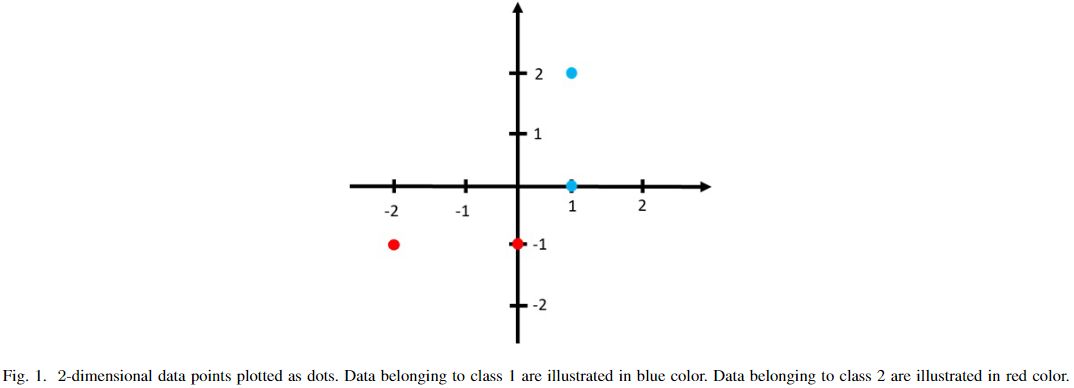

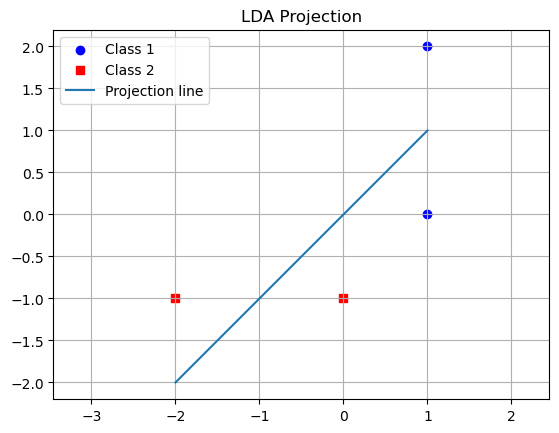

In [38]:
def plot_lda(X, t, w, colors=['b', 'r', 'g'], markers=['o', 's', '^']):
    plt.title("LDA Projection")
    plt.axis('equal')
    plt.grid()
    
    labels = np.unique(t)
    for i, label in enumerate(labels):
        plt.scatter(*X[t == label].T, label=f'Class {label}', color=colors[i], marker=markers[i])
    n = np.linspace(np.min(X[:,0])/w[0], np.max(X[:,0])/w[0], 100)
    plt.plot(n*w[0], n*w[1], label='Projection line')

    plt.legend()

plot_lda(X.T, l, w)